# Spotify Music Intelligence

## Exploratory Data Analysis (EDA)

### Objective

The purpose of this notebook is to explore the Spotify datasets and uncover meaningful insights about songs, artists, genres, and musical trends.

Every visualization in this notebook answers a business question that could help Spotify make better decisions.

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

songs = pd.read_csv("../data/raw/data.csv")
artists = pd.read_csv("../data/raw/data_by_artist.csv")
genres = pd.read_csv("../data/raw/data_by_genres.csv")
years = pd.read_csv("../data/raw/data_by_year.csv")
songs_with_genres = pd.read_csv("../data/raw/data_w_genres.csv")

## Business Question 1

How are Spotify songs distributed by popularity?

This helps us understand whether most songs become popular or whether only a small percentage achieve high popularity.

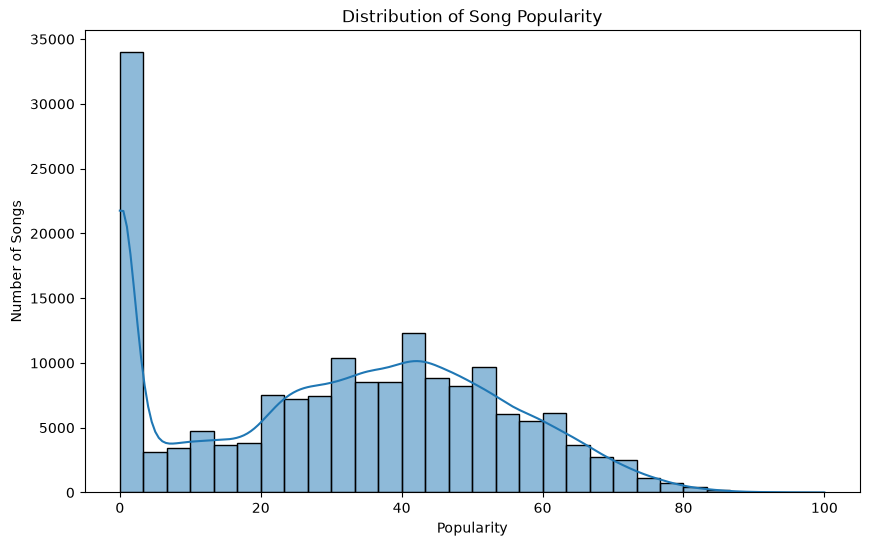

In [2]:
plt.figure(figsize=(10,6))

sns.histplot(
    songs["popularity"],
    bins=30,
    kde=True
)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

### Observation

The popularity distribution is right-skewed. Most songs have relatively low popularity, while only a small number achieve very high popularity, indicating that highly popular songs are relatively uncommon.

A significant spike at popularity **0** suggests that many songs in the dataset have little to no recent listener engagement. These are likely older, niche, or rarely streamed tracks. Another concentration of songs appears in the **30–50** popularity range, representing moderately popular songs, while the number of songs steadily decreases as popularity increases.

## Business Question 2

What are the most popular songs?

In [3]:
top_songs = songs.nlargest(10, "popularity")

top_songs[["name", "artists", "popularity"]]

,name,artists,popularity
19611,Dakiti,"['Bad Bunny', 'Jhay Cortez']",100
19606,Mood (feat. iann dior),"['24kGoldn', 'iann dior']",99
19618,Dynamite,['BTS'],97
19608,WAP (feat. Megan Thee Stallion),"['Cardi B', 'Megan Thee Stallion']",96
19610,positions,['Ariana Grande'],96
19612,What You Know Bout Love,['Pop Smoke'],96
19616,Blinding Lights,['The Weeknd'],96
19607,For The Night (feat. Lil Baby & DaBaby),"['Pop Smoke', 'Lil Baby', 'DaBaby']",95
19615,Holy (feat. Chance The Rapper),"['Justin Bieber', 'Chance the Rapper']",95
19620,Lonely (with benny blanco),"['Justin Bieber', 'benny blanco']",95


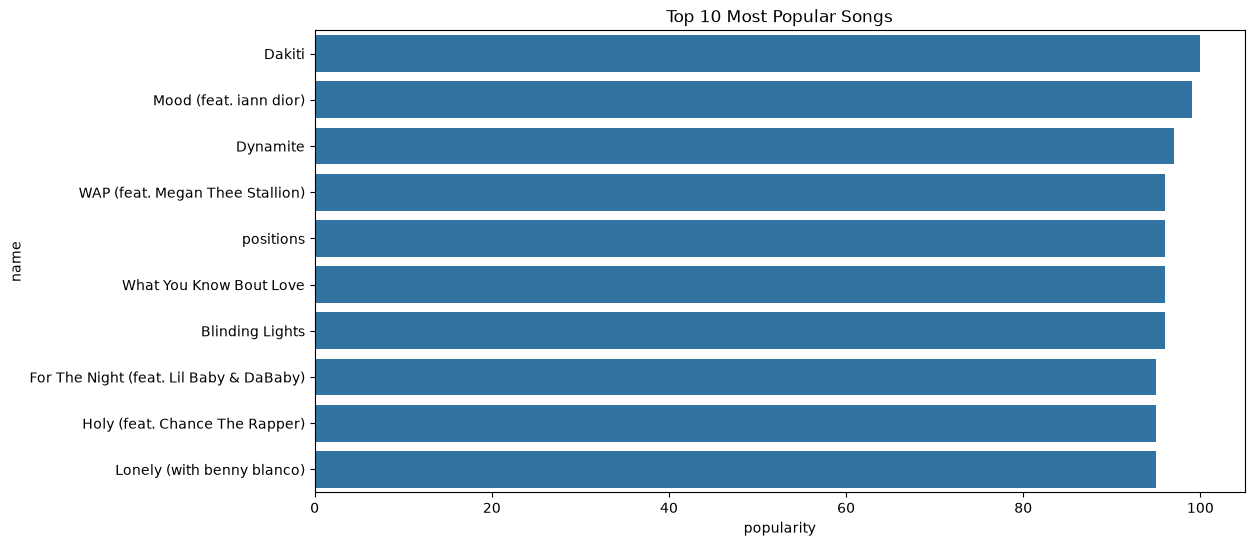

In [4]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_songs,
    x="popularity",
    y="name"
)

plt.title("Top 10 Most Popular Songs")

plt.show()

### Observation

The bar chart shows the top 10 most popular songs in the dataset, with popularity scores ranging from approximately 95 to 100. **Dakiti** is the most popular song, followed closely by **Mood (feat. iann dior)** and **Dynamite**. 

The small differences in popularity scores indicate that these songs were all highly successful and widely streamed during the period represented in the dataset. Overall, the chart highlights that only a few songs achieve exceptionally high popularity, making them stand out from the rest of the dataset.

## Business Question 3

Which artists have the highest average popularity?

In [5]:
top_artists = artists.sort_values(
    "popularity",
    ascending=False
).head(10)

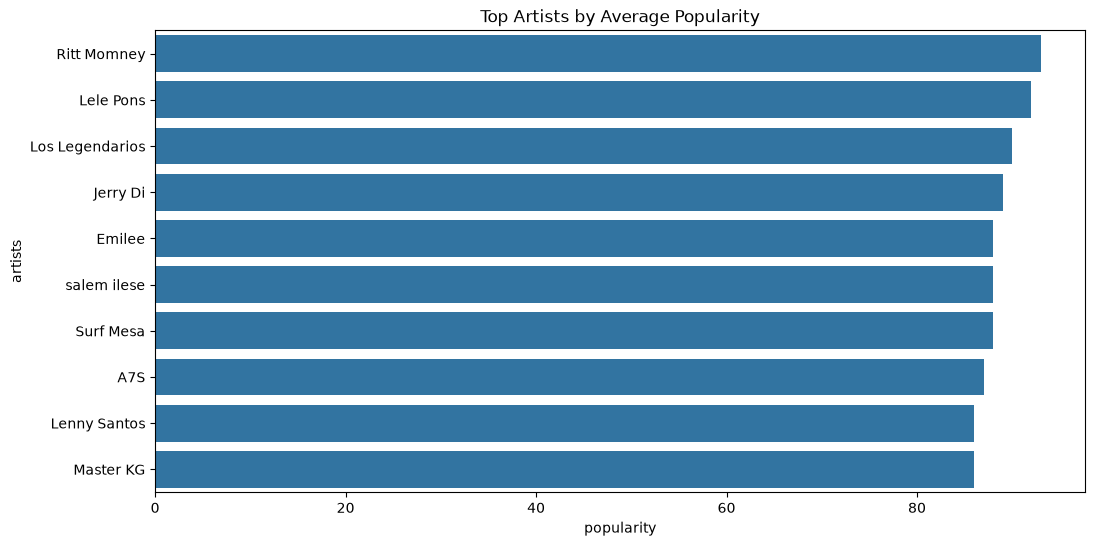

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_artists,
    x="popularity",
    y="artists"
)

plt.title("Top Artists by Average Popularity")

plt.show()

### Observation

The bar chart displays the top 10 artists with the highest average popularity in the dataset. **Ritt Momney** has the highest average popularity, followed closely by **Lele Pons** and **Los Legendarios**. 

The popularity scores of the top artists are relatively close, indicating that they all maintain a consistently high level of listener engagement. Overall, the chart suggests that only a small number of artists achieve exceptionally high average popularity, making them stand out from the rest of the artists in the dataset.

## Business Question 4

Which genres are the most popular?

In [7]:
top_genres = genres.sort_values(
    "popularity",
    ascending=False
).head(15)

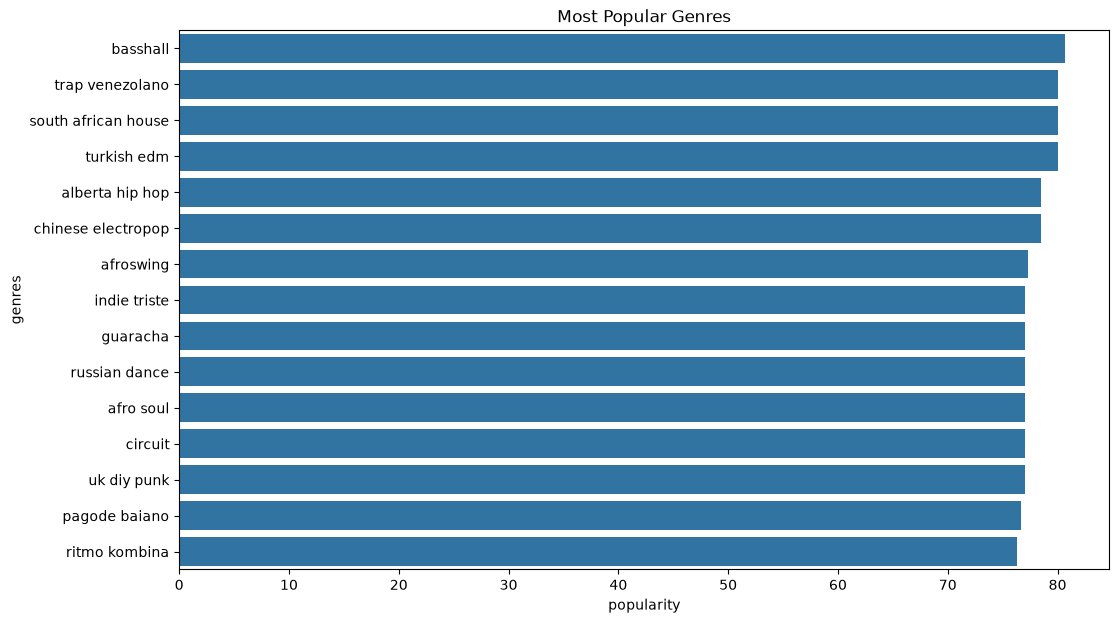

In [8]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_genres,
    x="popularity",
    y="genres"
)

plt.title("Most Popular Genres")

plt.show()

### Observation

The bar chart shows the top 15 genres with the highest average popularity in the dataset. **Basshall** ranks as the most popular genre, followed closely by **Trap Venezolano**, **South African House**, and **Turkish EDM**. 
    
The popularity scores of the leading genres are relatively close, indicating that several genres enjoy similar levels of listener engagement. Overall, the chart suggests that while a few genres consistently achieve high popularity, no single genre overwhelmingly dominates, reflecting a diverse range of popular music preferences among listeners.

## Business Question 5

Has music changed over time?

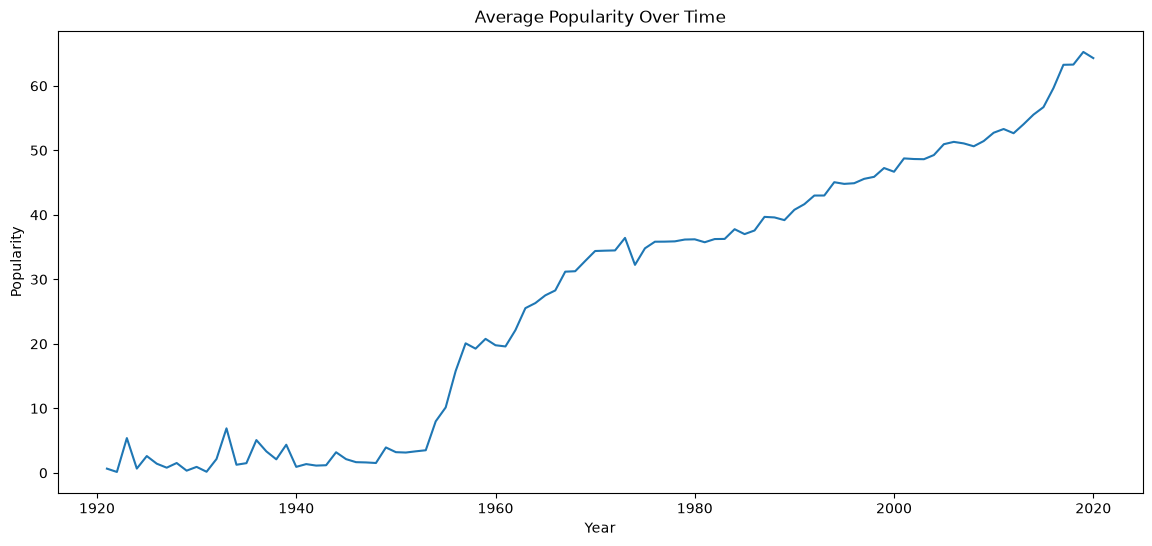

In [10]:
plt.figure(figsize=(14,6))

plt.plot(
    years["year"],
    years["popularity"]
)

plt.title("Average Popularity Over Time")

plt.xlabel("Year")

plt.ylabel("Popularity")

plt.show()

### Observation

The line chart shows that the average popularity of songs has generally increased over time. Songs released before the **1950s** have very low average popularity, while a noticeable rise begins in the **mid-1950s** and continues steadily through the following decades. The highest average popularity is observed in recent years (**2018–2020**), indicating that newer songs tend to receive greater listener engagement. Overall, the trend suggests that modern releases are significantly more popular than older songs in the dataset, likely due to changing listening habits and the influence of digital music streaming platforms.

## Business Question 6

Which audio features have the strongest relationship with song popularity?

Understanding these relationships helps identify which musical characteristics are associated with more popular songs.

In [11]:
numeric_df = songs.select_dtypes(include=np.number)

numeric_df.head()

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
0,0.0594,1921,0.982,0.279,831667,0.211,0,0.878000,10,0.665,-20.096,1,4,0.0366,80.954
1,0.9630,1921,0.732,0.819,180533,0.341,0,0.000000,7,0.160,-12.441,1,5,0.4150,60.936
2,0.0394,1921,0.961,0.328,500062,0.166,0,0.913000,3,0.101,-14.850,1,5,0.0339,110.339
3,0.1650,1921,0.967,0.275,210000,0.309,0,0.000028,5,0.381,-9.316,1,3,0.0354,100.109
4,0.2530,1921,0.957,0.418,166693,0.193,0,0.000002,3,0.229,-10.096,1,2,0.0380,101.665


In [12]:
correlation = numeric_df.corr()

correlation

,valence,year,acousticness,danceability,duration_ms,energy,explicit,instrumentalness,key,liveness,loudness,mode,popularity,speechiness,tempo
valence,1.000000,-0.028245,-0.184101,0.558946,-0.191813,0.353876,-0.018613,-0.198501,0.028473,0.003832,0.313512,0.015641,0.014200,0.046381,0.171689
year,-0.028245,1.000000,-0.614250,0.188515,0.079713,0.530272,0.220881,-0.272371,0.007540,-0.057318,0.487697,-0.032385,0.862442,-0.167816,0.141048
acousticness,-0.184101,-0.614250,1.000000,-0.266852,-0.076373,-0.749393,-0.246007,0.329819,-0.020550,-0.024482,-0.561696,0.047168,-0.573162,-0.043980,-0.207120
danceability,0.558946,0.188515,-0.266852,1.000000,-0.139937,0.221967,0.241757,-0.278063,0.024439,-0.100193,0.285057,-0.045956,0.199606,0.235491,0.001801
duration_ms,-0.191813,0.079713,-0.076373,-0.139937,1.000000,0.042119,-0.048880,0.084770,-0.004266,0.047168,-0.003037,-0.046085,0.059597,-0.084604,-0.025472
energy,0.353876,0.530272,-0.749393,0.221967,0.042119,1.000000,0.132723,-0.281101,0.027705,0.126192,0.782362,-0.039260,0.485005,-0.070555,0.250865
explicit,-0.018613,0.220881,-0.246007,0.241757,-0.048880,0.132723,1.000000,-0.140987,0.005432,0.039640,0.140300,-0.078872,0.191543,0.414070,0.011969
instrumentalness,-0.198501,-0.272371,0.329819,-0.278063,0.084770,-0.281101,-0.140987,1.000000,-0.014591,-0.047193,-0.408611,-0.036543,-0.296750,-0.121700,-0.105361
key,0.028473,0.007540,-0.020550,0.024439,-0.004266,0.027705,0.005432,-0.014591,1.000000,0.000205,0.017385,-0.116260,0.007826,0.023784,0.002629
liveness,0.003832,-0.057318,-0.024482,-0.100193,0.047168,0.126192,0.039640,-0.047193,0.000205,1.000000,0.056422,0.002641,-0.076464,0.134667,0.007714


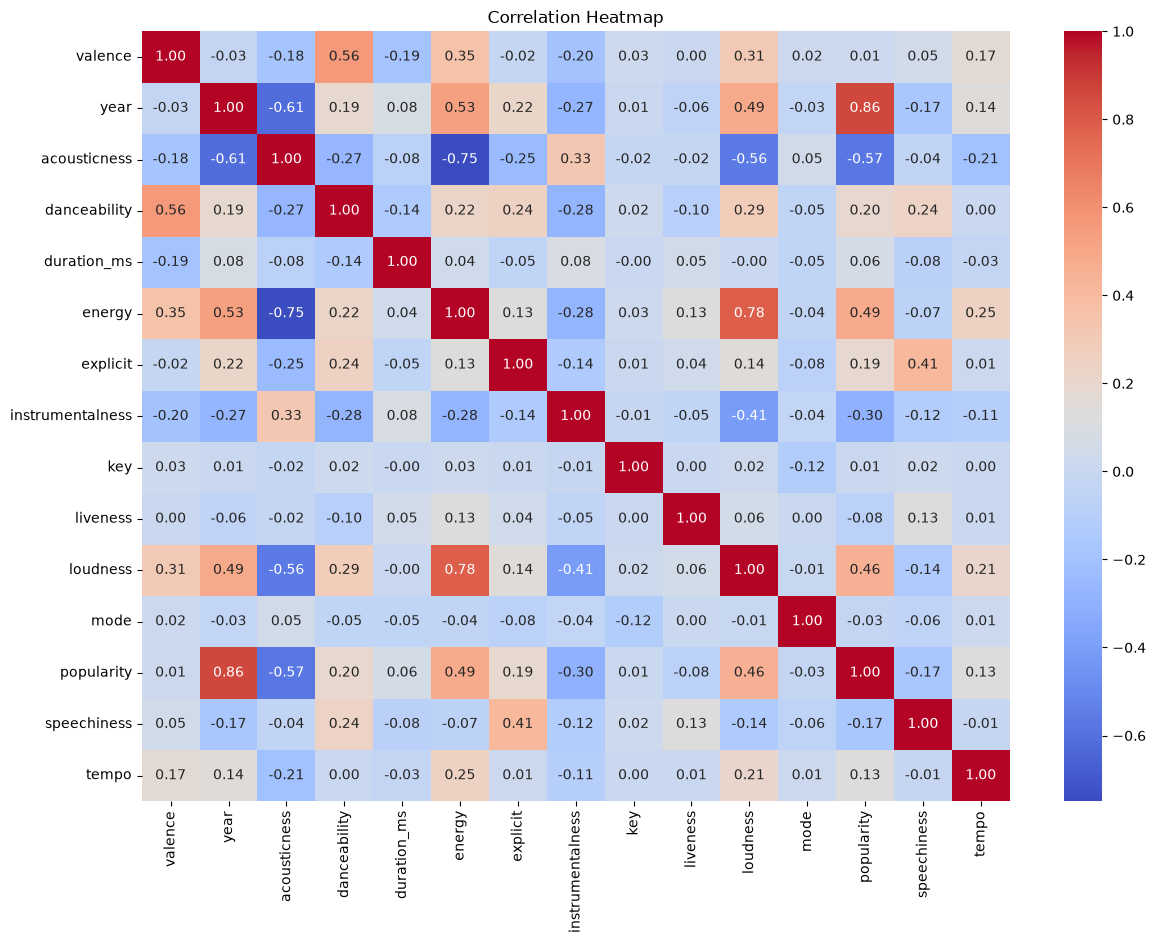

In [13]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The correlation heatmap shows the relationships between different song features, where values closer to **1** indicate a strong positive correlation, values closer to **-1** indicate a strong negative correlation, and values near **0** indicate little or no relationship. 

Some notable correlations include **year** and **popularity** (**0.86**), suggesting that newer songs tend to be more popular, and **energy** and **loudness** (**0.78**), indicating that energetic songs are generally louder. A strong negative correlation exists between **acousticness** and **energy** (**-0.75**), showing that acoustic songs are typically less energetic. Overall, most other feature pairs have weak to moderate correlations, suggesting that no single feature alone strongly determines a song's characteristics or popularity.

## Business Question 7

Which features correlate most with popularity?

In [14]:
correlation["popularity"].sort_values(ascending=False)

popularity          1.000000
year                0.862442
energy              0.485005
loudness            0.457051
danceability        0.199606
explicit            0.191543
tempo               0.133310
duration_ms         0.059597
valence             0.014200
key                 0.007826
mode               -0.028897
liveness           -0.076464
speechiness        -0.171979
instrumentalness   -0.296750
acousticness       -0.573162
Name: popularity, dtype: float64

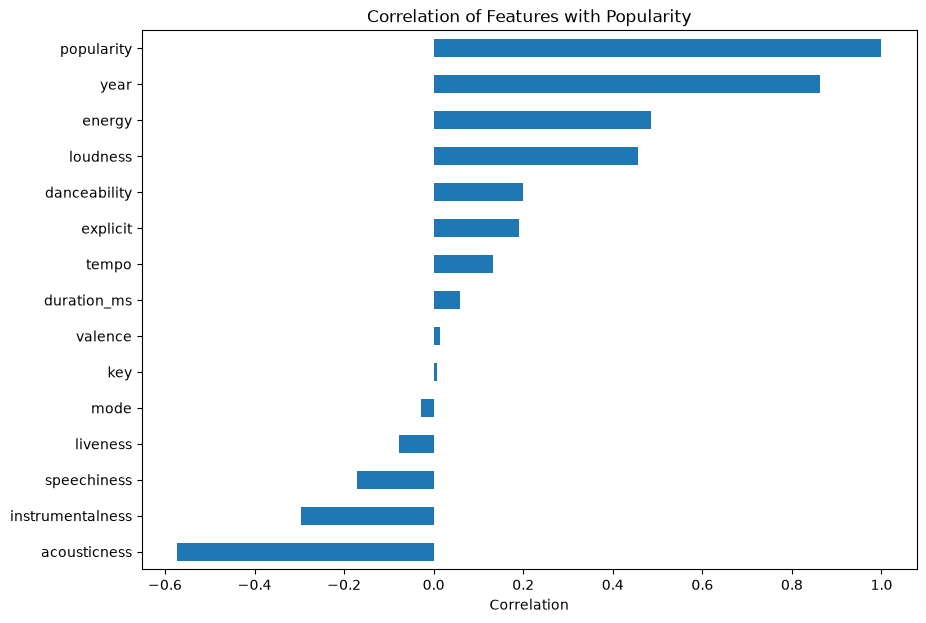

In [15]:
plt.figure(figsize=(10,7))

correlation["popularity"].sort_values().plot(kind="barh")

plt.title("Correlation of Features with Popularity")

plt.xlabel("Correlation")

plt.show()

### Observation

The chart shows how different audio features are correlated with song popularity. **Year** has the strongest positive correlation (**0.86**), indicating that newer songs tend to be more popular. **Energy** (**0.49**) and **Loudness** (**0.46**) also have moderate positive correlations, suggesting that energetic and louder songs generally receive higher popularity. In contrast, **Acousticness** (**-0.57**) has the strongest negative correlation, implying that highly acoustic songs are generally less popular. Most other features, such as **Danceability**, **Tempo**, **Valence**, and **Duration**, have weak correlations, indicating they have a relatively small individual influence on a song's popularity.

## Business Question 8

Does danceability influence popularity?

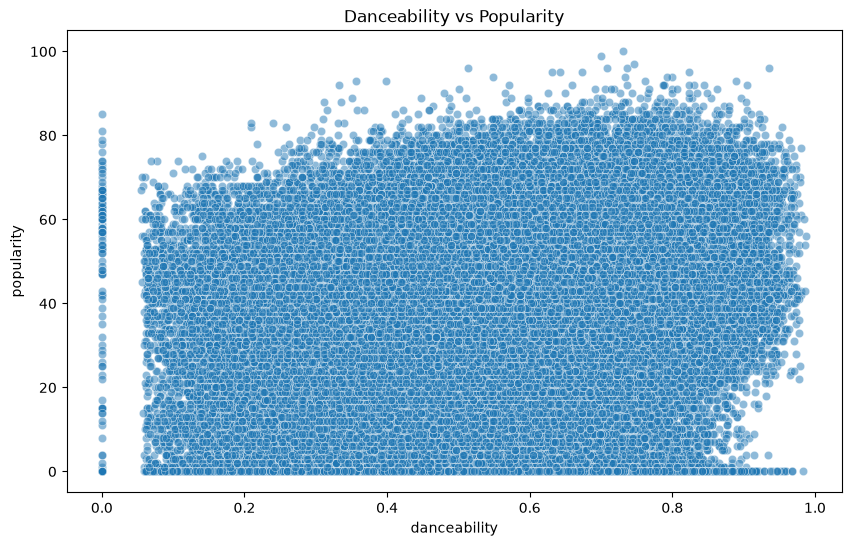

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=songs,
    x="danceability",
    y="popularity",
    alpha=0.5
)

plt.title("Danceability vs Popularity")

plt.show()

### Observation

The scatter plot illustrates the relationship between **danceability** and **popularity**. A weak positive trend can be observed, where songs with higher danceability tend to achieve slightly higher popularity. However, the points are widely scattered, indicating that danceability alone is not a strong predictor of a song's popularity. Popular songs are found across a broad range of danceability values, suggesting that other audio features and external factors also play an important role in determining a song's success.

## Business Question 9

Does energy influence popularity?

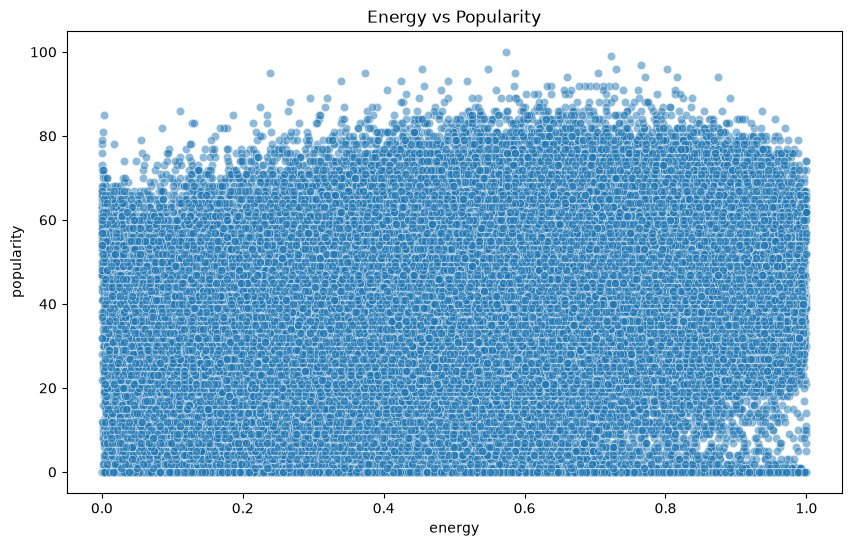

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=songs,
    x="energy",
    y="popularity",
    alpha=0.5
)

plt.title("Energy vs Popularity")

plt.show()

### Observation

The scatter plot shows the relationship between **energy** and **popularity**. A moderate positive trend can be observed, where songs with higher energy levels tend to achieve higher popularity. However, the points are still widely dispersed, indicating that energy alone does not determine a song's popularity. Highly popular songs are found across a range of energy values, suggesting that while energetic songs are generally more popular, other audio features and external factors also influence a song's overall success.

## Business Question 10

Does acousticness affect popularity?

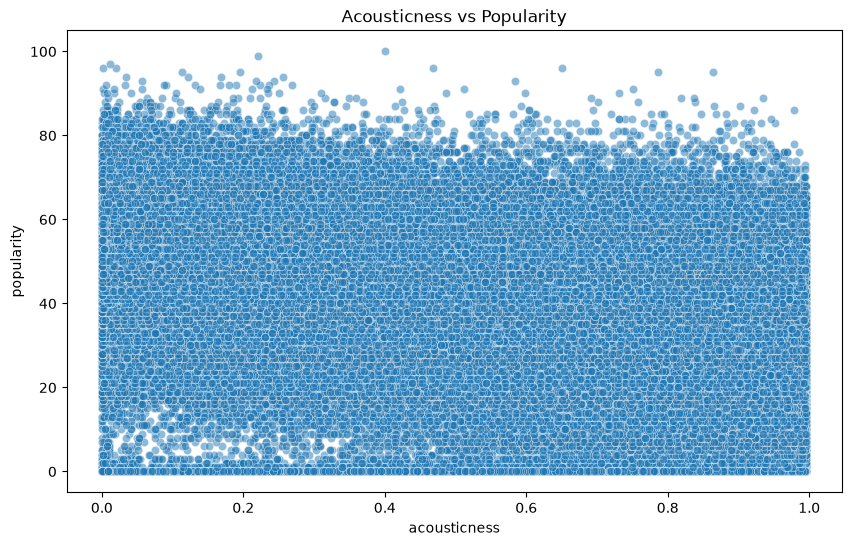

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=songs,
    x="acousticness",
    y="popularity",
    alpha=0.5
)

plt.title("Acousticness vs Popularity")

plt.show()

### Observation

The scatter plot shows the relationship between **acousticness** and **popularity**. A weak to moderate negative trend can be observed, where songs with higher acousticness generally tend to have lower popularity. However, the points remain widely scattered, indicating that acousticness alone is not a strong predictor of a song's popularity. Popular songs exist across different acousticness levels, suggesting that popularity is influenced by multiple audio features and external factors rather than acousticness alone.

## Business Question 11

Does tempo influence popularity?

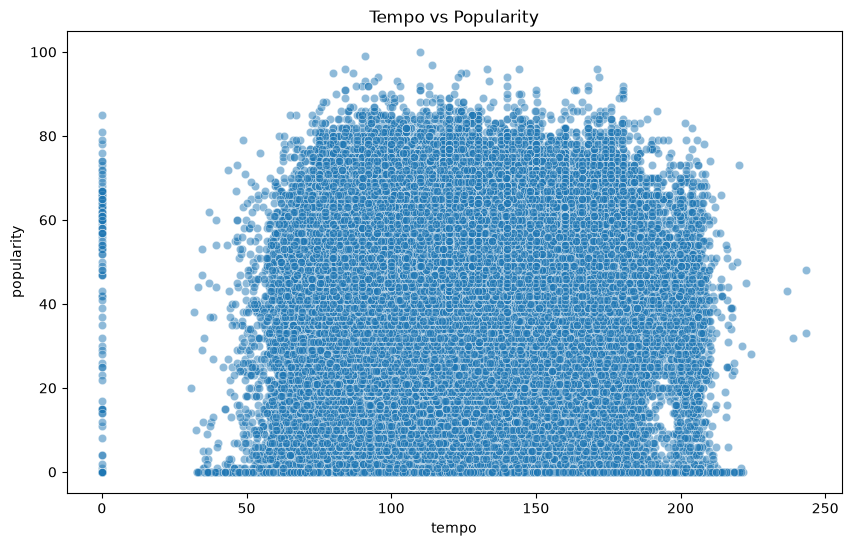

In [19]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=songs,
    x="tempo",
    y="popularity",
    alpha=0.5
)

plt.title("Tempo vs Popularity")

plt.show()

### Observation

The scatter plot shows the relationship between **tempo** and **popularity**. No strong relationship is observed, as the data points are widely dispersed across different tempo values. Most songs fall within the **80–180 BPM** range, where both high- and low-popularity songs are present. This indicates that tempo alone has little influence on a song's popularity, and other audio features and external factors are likely to play a more significant role in determining a song's success.

## Business Question 12

What is the distribution of audio features?

In [20]:
audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence"
]

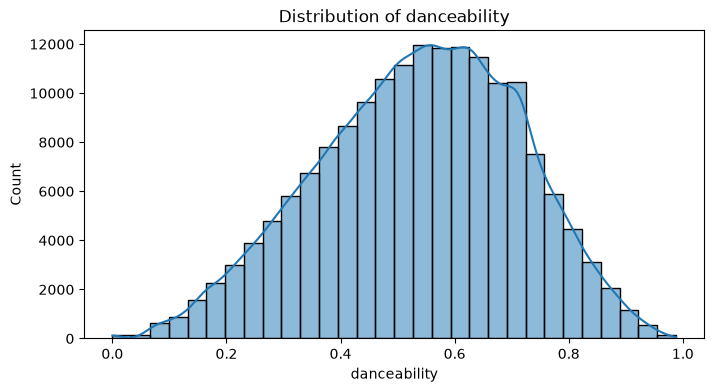

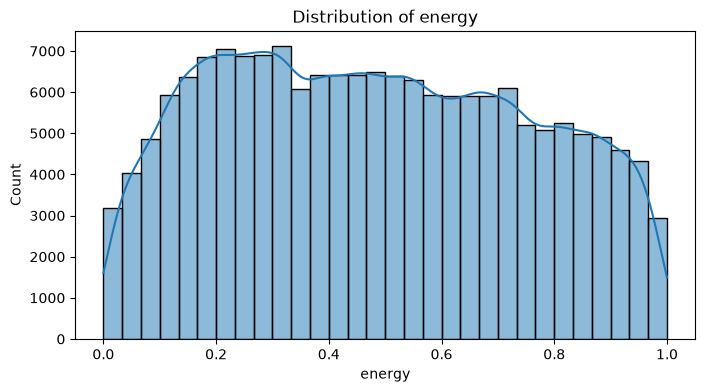

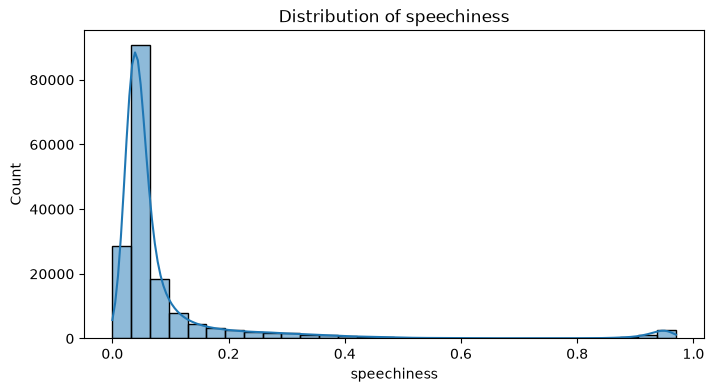

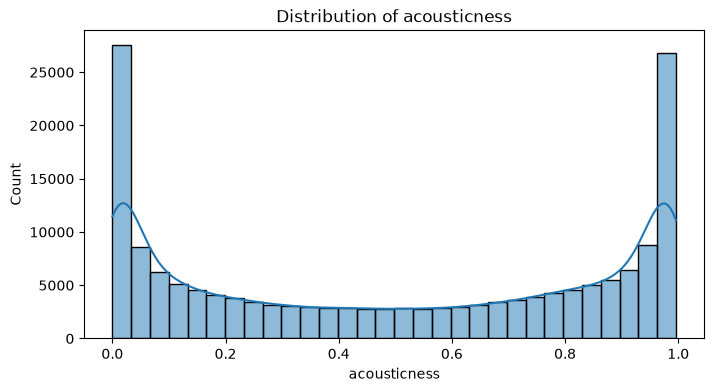

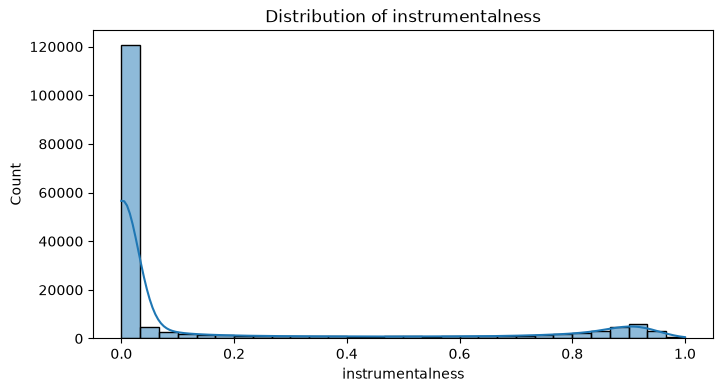

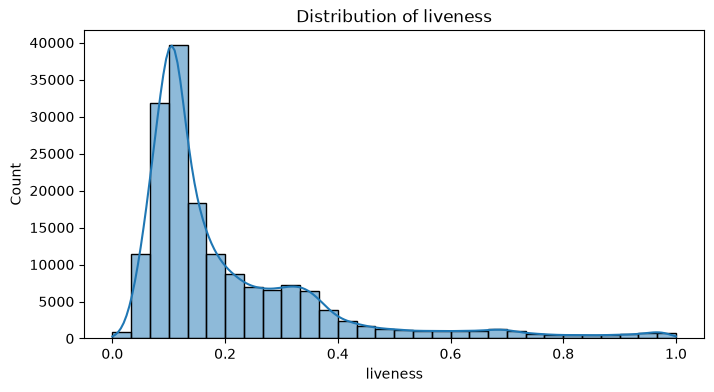

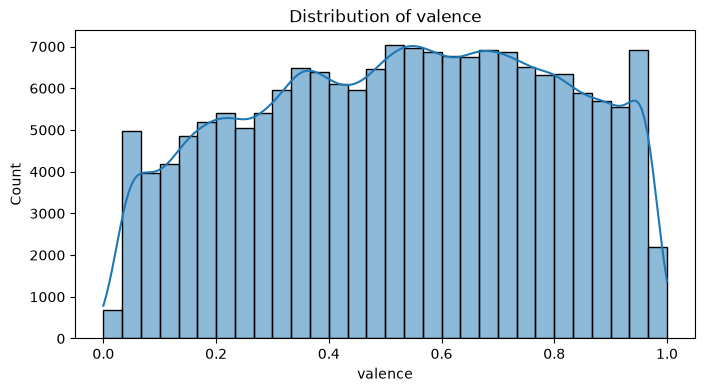

In [21]:
for feature in audio_features:

    plt.figure(figsize=(8,4))

    sns.histplot(
        songs[feature],
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")

    plt.show()

### Observation

The distribution plots reveal that each audio feature has a unique pattern, highlighting the diversity of characteristics present in the songs. **Danceability** follows an approximately bell-shaped distribution, with most songs having moderate values between **0.4** and **0.7**, indicating that the majority of tracks are reasonably suitable for dancing. **Energy** is fairly evenly distributed across the range, suggesting that the dataset includes a balanced mix of calm, moderate, and highly energetic songs.

In contrast, **Speechiness**, **Instrumentalness**, and **Liveness** exhibit highly right-skewed distributions. Most songs have very low values for these features, indicating that the majority are vocal studio recordings with little spoken content and minimal instrumental-only compositions. Only a small proportion of songs have high speechiness, are fully instrumental, or represent live performances.

**Acousticness** displays a clear bimodal distribution, with peaks near **0** and **1**. This suggests that songs in the dataset tend to be either highly acoustic or minimally acoustic, while relatively few songs have moderate acousticness values. **Valence**, which measures the musical positivity or happiness of a song, follows an approximately bell-shaped distribution with a slight concentration around moderate to high values. This indicates that the dataset contains a balanced mix of songs with different emotional tones, with many songs conveying neutral to positive moods.

Overall, these distributions show that the dataset contains a wide variety of musical styles and audio characteristics. While some features, such as **Danceability** and **Valence**, are centered around moderate values, others, including **Speechiness**, **Instrumentalness**, and **Liveness**, are dominated by low values. This variation suggests that the dataset is diverse and provides a strong foundation for further analysis and predictive modeling of song popularity.

## Business Question 13

Which songs are the happiest?

In [22]:
songs.nlargest(10, "valence")[
    ["name", "artists", "valence"]
]

,name,artists,valence
29984,Les Petites Marionettes,['Raffi'],1.000
40649,Chatter,['Raymond Scott'],1.000
53764,Pasito Duranguense,['Montez de Durango'],1.000
105668,Electric Zoo,['Spongebob Squarepants'],1.000
104780,Barney Theme Song,['Barney'],0.998
52181,Barney Theme Song,['Barney'],0.996
166743,La Pava,['Montez de Durango'],0.996
77567,"Violin Partita No. 3 in E Major, BWV 1006: VI....","['Johann Sebastian Bach', 'Jascha Heifetz']",0.995
71471,El Sube Y Baja,['Montez de Durango'],0.994
119633,La Basurita,['Banda El Recodo'],0.994


### Observation

Spotify measures the emotional positivity of a song using **Valence**, where values range from **0** to **1**.

- **Higher Valence** → Happier songs
- **Lower Valence** → Sadder songs

The table displays the **top 10 happiest songs** in the dataset based on their valence scores. Several songs, including **Les Petites Marionettes**, **Chatter**, **Pasito Duranguense**, and **Electric Zoo**, have the maximum valence score of **1.000**, indicating they are considered the happiest songs according to Spotify's audio analysis. The remaining songs also have very high valence values (above **0.99**), suggesting they convey highly positive and uplifting moods.

## Business Question 14

Which songs are the saddest?

In [23]:
songs.nsmallest(10, "valence")[
    ["name", "artists", "valence"]
]

,name,artists,valence
508,La Mina del Ford - Remasterizado,['Ignacio Corsini'],0.0
591,Oh Mujer Mujer - Remasterizado,['Francisco Canaro'],0.0
978,"Cuatro melodías al unísono, No. III",['Iván Rolón'],0.0
2578,Santa Claus Is Coming To Town,['The Moors'],0.0
2764,Tu Y Yo,['Orquesta Francisco Canaro'],0.0
3042,Back In Your Own Backyard - Take 1,['Billie Holiday'],0.0
3532,If I Were King of the Forest - Partial Take; A...,"['Bert Lahr', 'Judy Garland', 'Ray Bolger', 'B...",0.0
3533,Munchkinland Insert - Alternate Tag,['MGM Studio Orchestra'],0.0
3968,The Christmas Raid,['The Slobs'],0.0
5574,"Embraceable You - Live At Carnegie Hall, New Y...",['Charlie Parker'],0.0


### Observation

Spotify measures the emotional positivity of a song using **Valence**, where values range from **0** to **1**.

- **Higher Valence** → Happier songs
- **Lower Valence** → Sadder songs

The table displays the **top 10 saddest songs** in the dataset based on their valence scores. All of the listed songs have the minimum valence score of **0.000**, indicating that they are considered the saddest songs according to Spotify's audio analysis. These songs are expected to convey negative, melancholic, or emotionally subdued moods. While valence reflects a song's emotional tone, it does not necessarily indicate the song's genre or lyrical content.

## Business Question 15

Which songs are the fastest?

In [24]:
songs.nlargest(10, "tempo")[
    ["name", "artists", "tempo"]
]

,name,artists,tempo
82884,I Don't Want You on My Mind,['Bill Withers'],243.507
29113,Call The Doctor,['J.J. Cale'],243.372
64511,Dear Landlord,['Bob Dylan'],238.895
28559,Candyman - 2013 Remaster,['Grateful Dead'],236.799
164226,Surrender - 2005 Remastered Version,['Suicide'],224.437
120350,Undenied,['Portishead'],222.605
2517,Biyer Pare,['Bimal Gupta'],221.741
134328,L Dopa,['Big Black'],221.112
22909,To xaremi sto xamam,['Anestis Delias'],221.058
125201,To xaremi sto xamam,['Anestis Delias'],221.058


### Observation

**Tempo** measures the speed of a song in **beats per minute (BPM)**. Higher tempo values indicate faster-paced songs, while lower values represent slower-paced songs.

The table lists the **top 10 fastest songs** in the dataset based on their tempo values. **I Don't Want You on My Mind** by **Bill Withers** has the highest recorded tempo at **243.507 BPM**, followed closely by **Call The Doctor** and **Dear Landlord**. Most of the songs in the list have tempo values exceeding **220 BPM**, making them significantly faster than the average song. These tracks span a variety of artists and genres, suggesting that exceptionally high tempo is not limited to a single style of music. While these songs are the fastest in the dataset, a high tempo does not necessarily imply greater popularity or listener preference.